In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Load cleaned datasets
customers = pd.read_csv(r"cleaned_data\customers_clean.csv")
orders = pd.read_csv(r"cleaned_data\orders_clean.csv")
payments = pd.read_csv(r"cleaned_data\payments_clean.csv")

# Convert date columns
customers["customer_since"] = pd.to_datetime(customers["customer_since"], format="mixed", errors="coerce")
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], format="mixed", errors="coerce")
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"], format="mixed", errors="coerce")
orders["order_delivered_timestamp"] = pd.to_datetime(orders["order_delivered_timestamp"], format="mixed", errors="coerce")
orders["order_estimated_delivery"] = pd.to_datetime(orders["order_estimated_delivery"], format="mixed", errors="coerce")

# Helpful formatters
comma_fmt = mticker.StrMethodFormatter("{x:,.0f}")
def rupee(x):
    return f"₹{x:,.2f}"

def crore(x):
    return f"₹{x/1e7:,.2f} Cr"

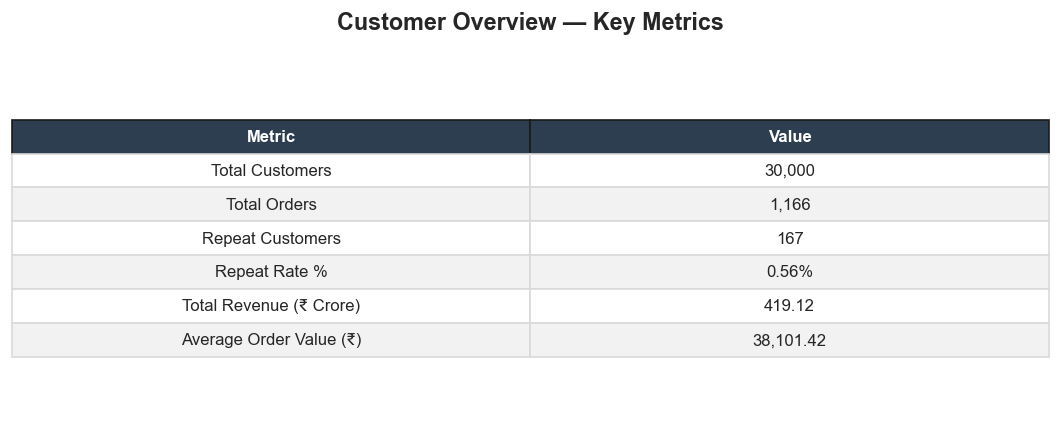

Raw KPI Values:
Total Customers: 30,000
Total Orders: 1,166
Repeat Customers: 167
Repeat Rate %: 0.56%
Total Revenue: ₹4,191,156,400.79 (419.12 Cr)
Average Order Value: ₹38,101.42


In [2]:
# =========================
# Section 2: KPI Summary
# =========================

# Merge orders + customers + payments
orders_payments = orders.merge(payments, on="order_id", how="left")
master_kpi = orders_payments.merge(
    customers[["customer_id", "customer_name", "customer_city", "customer_state"]],
    on="customer_id",
    how="left"
)

# KPI calculations
total_customers = customers["customer_id"].nunique()
total_orders = orders["order_id"].nunique()

orders_per_customer = orders.groupby("customer_id")["order_id"].nunique()
repeat_customers = (orders_per_customer > 1).sum()
repeat_rate = (repeat_customers / total_customers) * 100

total_revenue = payments["payment_value"].sum()
avg_order_value = payments["payment_value"].mean()

kpi_table = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Orders",
        "Repeat Customers",
        "Repeat Rate %",
        "Total Revenue (₹ Crore)",
        "Average Order Value (₹)"
    ],
    "Value": [
        f"{total_customers:,}",
        f"{total_orders:,}",
        f"{repeat_customers:,}",
        f"{repeat_rate:.2f}%",
        f"{total_revenue/1e7:,.2f}",
        f"{avg_order_value:,.2f}"
    ]
})

# Styled matplotlib table
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axis("off")
ax.set_title("Customer Overview — Key Metrics", fontsize=14, fontweight="bold", pad=14)

tbl = ax.table(
    cellText=kpi_table.values,
    colLabels=kpi_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

# Header styling
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#f2f2f2" if row % 2 == 0 else "white")
        cell.set_edgecolor("#d9d9d9")

plt.tight_layout()
plt.show()

print("Raw KPI Values:")
print(f"Total Customers: {total_customers:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Repeat Customers: {repeat_customers:,}")
print(f"Repeat Rate %: {repeat_rate:.2f}%")
print(f"Total Revenue: ₹{total_revenue:,.2f} ({total_revenue/1e7:,.2f} Cr)")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")

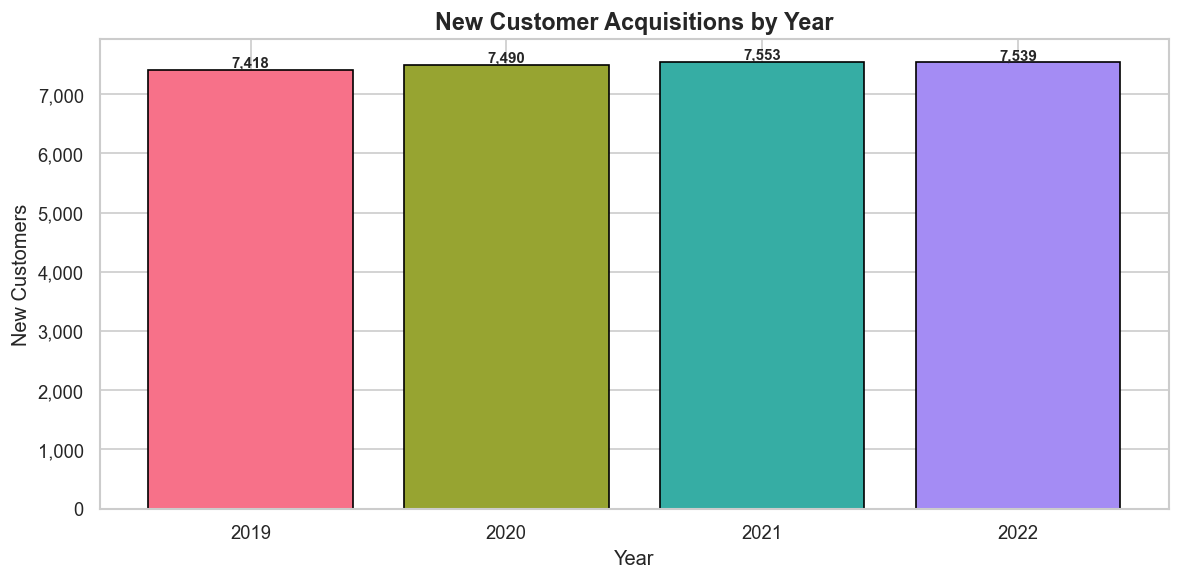

Summary Table:


,Year,New Customers,YoY Growth %
0,2019,7418,-
1,2020,7490,0.97%
2,2021,7553,0.84%
3,2022,7539,-0.19%


In [3]:
# =========================
# Section 3: Customer Growth — New Customers by Year
# =========================

customers_year = customers.copy()
customers_year["year"] = customers_year["customer_since"].dt.year

growth_df = (
    customers_year.groupby("year", dropna=True)["customer_id"]
    .nunique()
    .reset_index(name="New Customers")
    .sort_values("year")
)

growth_df["YoY Growth %"] = growth_df["New Customers"].pct_change() * 100

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

year_colors = sns.color_palette("husl", n_colors=len(growth_df))
bars = ax.bar(growth_df["year"].astype(str), growth_df["New Customers"], color=year_colors, edgecolor="black")

ax.set_title("New Customer Acquisitions by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("New Customers")
ax.yaxis.set_major_formatter(comma_fmt)
ax.tick_params(axis="x", rotation=0)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Summary table
summary_growth = growth_df.copy()
summary_growth["YoY Growth %"] = summary_growth["YoY Growth %"].round(2)
summary_growth["YoY Growth %"] = summary_growth["YoY Growth %"].map(lambda x: "-" if pd.isna(x) else f"{x:.2f}%")

print("Summary Table:")
display(summary_growth.rename(columns={"year": "Year"}))

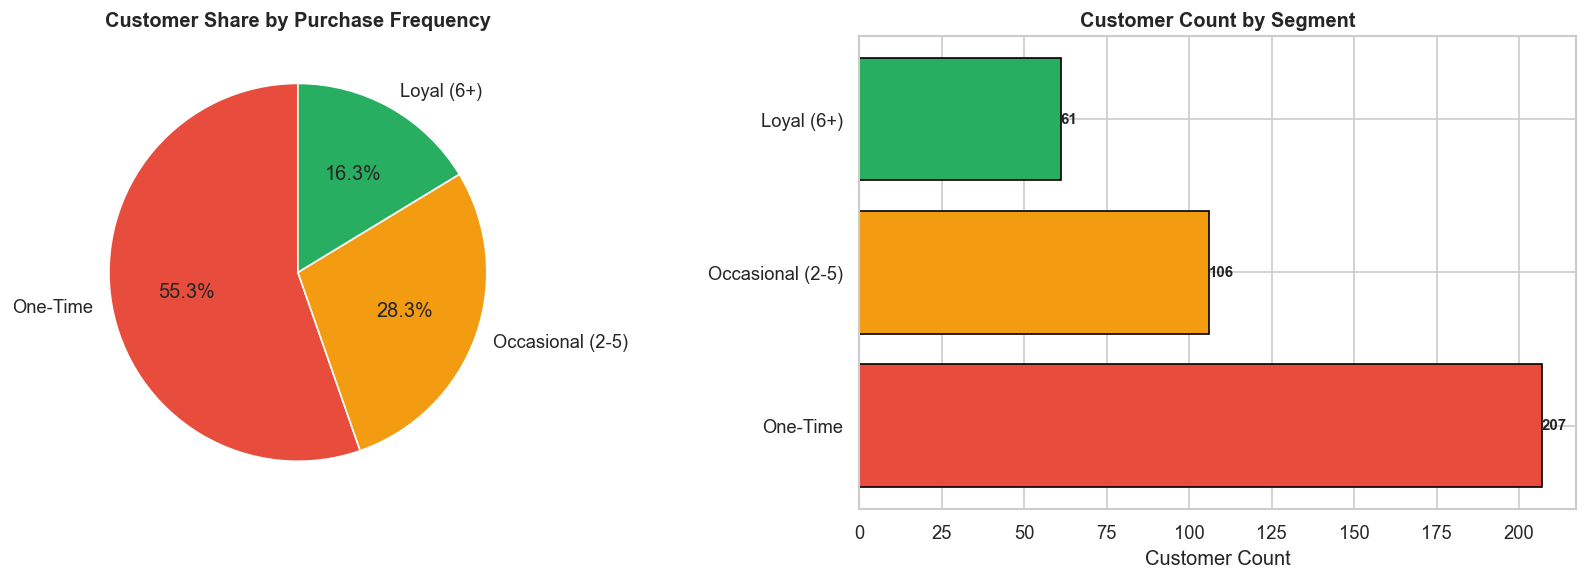

Segment Summary Table:


,segment,customers,share %
0,One-Time,207,55.347594
1,Occasional (2-5),106,28.342246
2,Loyal (6+),61,16.310160


In [4]:
# =========================
# Section 4: Customer Segmentation by Purchase Frequency
# =========================

purchase_counts = orders.groupby("customer_id")["order_id"].nunique().reset_index(name="order_count")

def segment_customer(n):
    if n == 1:
        return "One-Time"
    elif 2 <= n <= 5:
        return "Occasional (2-5)"
    else:
        return "Loyal (6+)"

purchase_counts["segment"] = purchase_counts["order_count"].apply(segment_customer)

segment_order = ["One-Time", "Occasional (2-5)", "Loyal (6+)"]
segment_colors = {
    "One-Time": "#e74c3c",
    "Occasional (2-5)": "#f39c12",
    "Loyal (6+)": "#27ae60"
}

segment_summary = (
    purchase_counts.groupby("segment")
    .agg(customers=("customer_id", "nunique"))
    .reindex(segment_order)
    .reset_index()
)

segment_summary["share %"] = (segment_summary["customers"] / segment_summary["customers"].sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Pie chart
axes[0].pie(
    segment_summary["customers"],
    labels=segment_summary["segment"],
    autopct="%1.1f%%",
    startangle=90,
    colors=[segment_colors[s] for s in segment_summary["segment"]],
    wedgeprops={"edgecolor": "white"}
)
axes[0].set_title("Customer Share by Purchase Frequency", fontweight="bold")

# Right: Horizontal bar chart
bars = axes[1].barh(
    segment_summary["segment"],
    segment_summary["customers"],
    color=[segment_colors[s] for s in segment_summary["segment"]],
    edgecolor="black"
)
axes[1].set_title("Customer Count by Segment", fontweight="bold")
axes[1].set_xlabel("Customer Count")
axes[1].xaxis.set_major_formatter(comma_fmt)

for bar in bars:
    width = bar.get_width()
    axes[1].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("Segment Summary Table:")
display(segment_summary)

States covered        : 15
Top state by revenue  : Telangana  (₹0.45 Cr)
Top state by customers: Rajasthan  (33 customers)


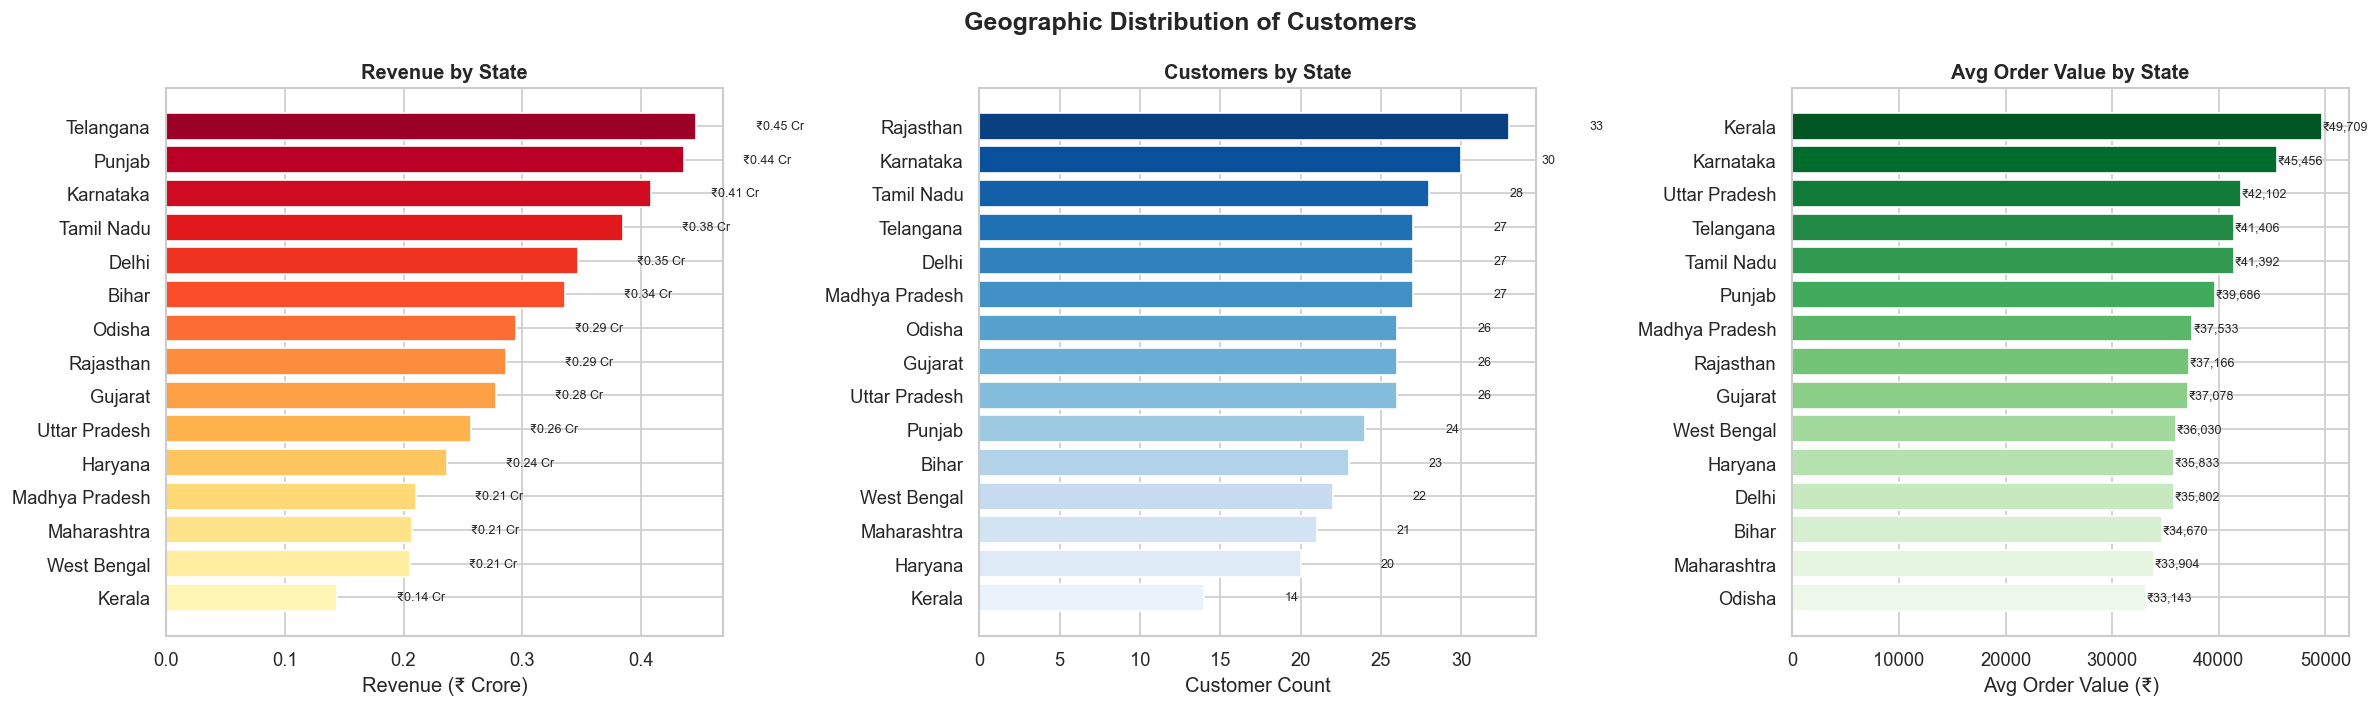

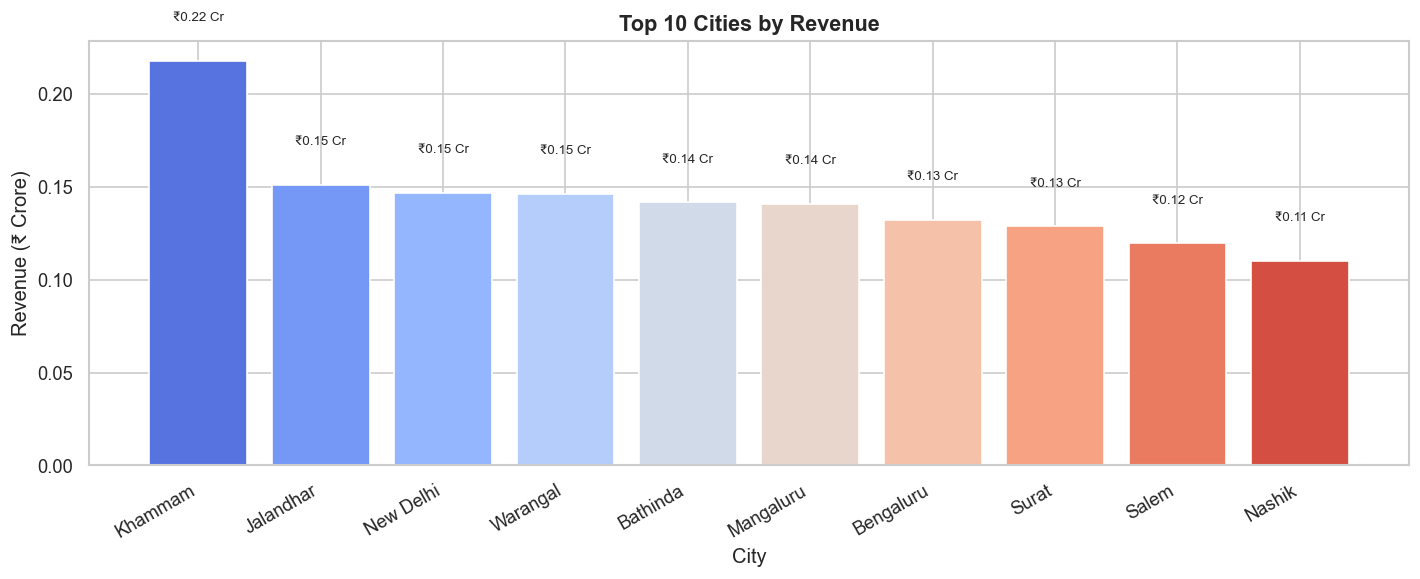


── State Summary Table ──


,customer_state,Customer_Count,Total_Orders,Revenue_Cr,Avg_Order_Value
0,Telangana,27,108,0.447182,41405.723148
1,Punjab,24,110,0.436547,39686.131455
2,Karnataka,30,90,0.409102,45455.795222
3,Tamil Nadu,28,93,0.384944,41391.819247
4,Delhi,27,97,0.347276,35801.682990
5,Bihar,23,97,0.336302,34670.351546
6,Odisha,26,89,0.294977,33143.489101
7,Rajasthan,33,77,0.286177,37165.843247
8,Gujarat,26,75,0.278082,37077.618933
9,Uttar Pradesh,26,61,0.256821,42101.821475


In [10]:
# =========================
# Section 5: Geographic Distribution of Customers
# =========================

geo_base = orders.merge(payments, on="order_id", how="left").merge(
    customers[["customer_id", "customer_state", "customer_city"]], on="customer_id", how="left"
)

# ── State-level aggregation ───────────────────────────────────────────────────
state_df = (
    geo_base.groupby("customer_state")
    .agg(
        Customer_Count=("customer_id", "nunique"),
        Total_Revenue=("payment_value", "sum"),
        Total_Orders=("order_id", "nunique"),
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)
state_df["Avg_Order_Value"] = state_df["Total_Revenue"] / state_df["Total_Orders"]
state_df["Revenue_Cr"]      = state_df["Total_Revenue"] / 1e7

# ── City-level top 10 ─────────────────────────────────────────────────────────
city_df = (
    geo_base.groupby("customer_city")
    .agg(Customer_Count=("customer_id", "nunique"), Revenue=("payment_value", "sum"))
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
)

# ── KPI print ─────────────────────────────────────────────────────────────────
top_state_rev  = state_df.iloc[0]
top_state_cust = state_df.sort_values("Customer_Count", ascending=False).iloc[0]
print(f"States covered        : {state_df['customer_state'].nunique()}")
print(f"Top state by revenue  : {top_state_rev['customer_state']}  ({crore(top_state_rev['Total_Revenue'])})")
print(f"Top state by customers: {top_state_cust['customer_state']}  ({top_state_cust['Customer_Count']:,} customers)")

# ── Figure 1 : State charts ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Geographic Distribution of Customers", fontsize=15, fontweight="bold")

palette_rev  = sns.color_palette("YlOrRd",  len(state_df))[::-1]
palette_cust = sns.color_palette("Blues",   len(state_df))[::-1]
palette_aov  = sns.color_palette("Greens",  len(state_df))[::-1]

# Revenue by state
ax1 = axes[0]
bars = ax1.barh(state_df["customer_state"], state_df["Revenue_Cr"], color=palette_rev)
ax1.invert_yaxis()
ax1.set_xlabel("Revenue (₹ Crore)")
ax1.set_title("Revenue by State", fontweight="bold")
for bar, val in zip(bars, state_df["Revenue_Cr"]):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             f"₹{val:.2f} Cr", va="center", fontsize=7.5)

# Customer count by state
ax2 = axes[1]
cust_sorted = state_df.sort_values("Customer_Count", ascending=False)
bars2 = ax2.barh(cust_sorted["customer_state"], cust_sorted["Customer_Count"], color=palette_cust)
ax2.invert_yaxis()
ax2.set_xlabel("Customer Count")
ax2.set_title("Customers by State", fontweight="bold")
for bar in bars2:
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"{int(bar.get_width()):,}", va="center", fontsize=7.5)

# Avg order value by state
ax3 = axes[2]
aov_sorted = state_df.sort_values("Avg_Order_Value", ascending=False)
bars3 = ax3.barh(aov_sorted["customer_state"], aov_sorted["Avg_Order_Value"], color=palette_aov)
ax3.invert_yaxis()
ax3.set_xlabel("Avg Order Value (₹)")
ax3.set_title("Avg Order Value by State", fontweight="bold")
for bar in bars3:
    ax3.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
             f"₹{bar.get_width():,.0f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.show()

# ── Figure 2 : Top 10 cities ──────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(12, 5))
palette_city = sns.color_palette("coolwarm", len(city_df))
bars4 = ax.bar(city_df["customer_city"], city_df["Revenue"] / 1e7,
               color=palette_city, edgecolor="white")
ax.set_title("Top 10 Cities by Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Revenue (₹ Crore)")
plt.xticks(rotation=30, ha="right")
for bar in bars4:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"₹{bar.get_height():.2f} Cr", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print("\n── State Summary Table ──")
display(state_df[["customer_state","Customer_Count","Total_Orders","Revenue_Cr","Avg_Order_Value"]].reset_index(drop=True))


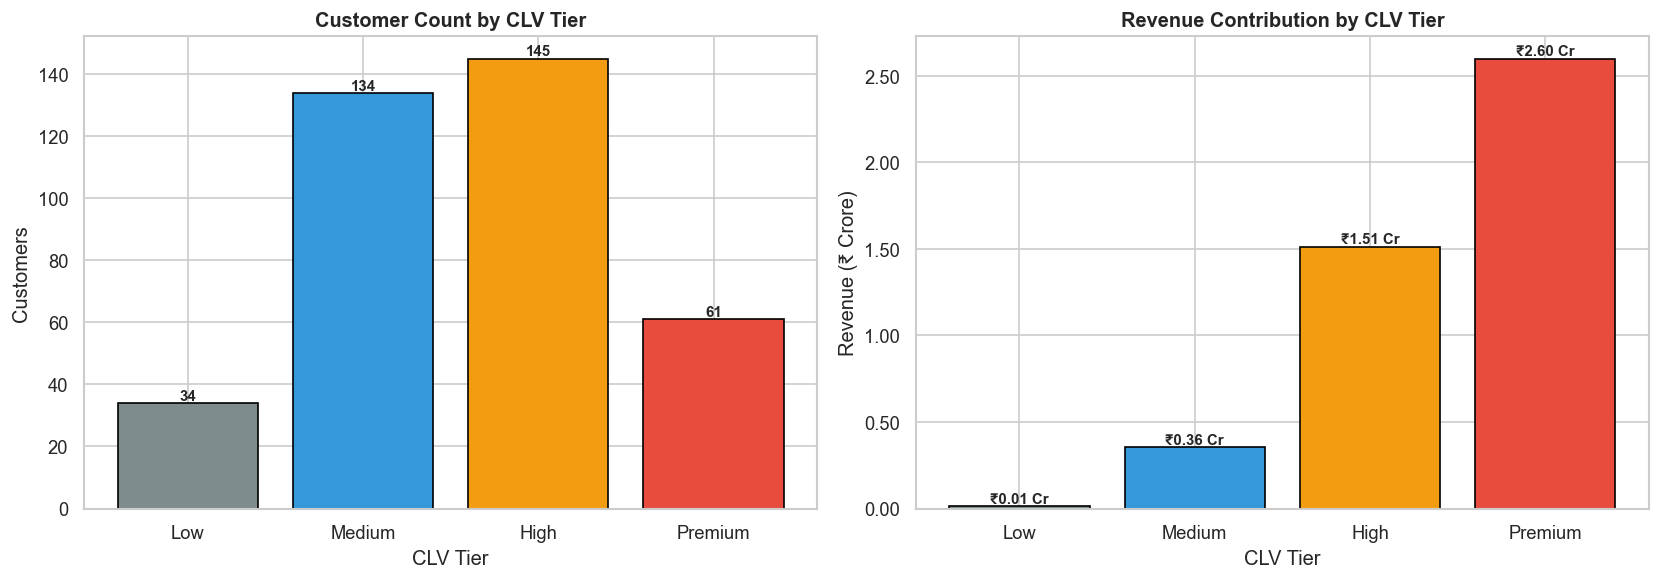

CLV Summary Table:


,CLV Tier,Customers,Total Revenue,Avg CLV
0,Low,34,"₹118,998.24","₹3,499.95"
1,Medium,134,"₹3,556,882.17","₹26,543.90"
2,High,145,"₹15,132,387.21","₹104,361.29"
3,Premium,61,"₹25,996,051.29","₹426,164.78"


In [5]:
# =========================
# Section 6: Customer Lifetime Value (CLV) Analysis
# =========================

clv_base = orders.merge(payments, on="order_id", how="left")

clv_df = (
    clv_base.groupby("customer_id")
    .agg(clv=("payment_value", "sum"))
    .reset_index()
)

clv_bins = [0, 10000, 50000, 200000, np.inf]
clv_labels = ["Low", "Medium", "High", "Premium"]

clv_df["clv_tier"] = pd.cut(
    clv_df["clv"],
    bins=clv_bins,
    labels=clv_labels,
    include_lowest=True
)

clv_summary = (
    clv_df.groupby("clv_tier", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        total_revenue=("clv", "sum"),
        avg_clv=("clv", "mean")
    )
    .reindex(clv_labels)
    .reset_index()
)

clv_summary["Total Revenue (₹ Crore)"] = clv_summary["total_revenue"] / 1e7

tier_colors = {
    "Low": "#7f8c8d",
    "Medium": "#3498db",
    "High": "#f39c12",
    "Premium": "#e74c3c"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: customer count per CLV tier
bars1 = axes[0].bar(
    clv_summary["clv_tier"].astype(str),
    clv_summary["customers"],
    color=[tier_colors[t] for t in clv_summary["clv_tier"].astype(str)],
    edgecolor="black"
)
axes[0].set_title("Customer Count by CLV Tier", fontweight="bold")
axes[0].set_xlabel("CLV Tier")
axes[0].set_ylabel("Customers")
axes[0].yaxis.set_major_formatter(comma_fmt)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Right: revenue contribution per CLV tier in ₹ Crore
bars2 = axes[1].bar(
    clv_summary["clv_tier"].astype(str),
    clv_summary["Total Revenue (₹ Crore)"],
    color=[tier_colors[t] for t in clv_summary["clv_tier"].astype(str)],
    edgecolor="black"
)
axes[1].set_title("Revenue Contribution by CLV Tier", fontweight="bold")
axes[1].set_xlabel("CLV Tier")
axes[1].set_ylabel("Revenue (₹ Crore)")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}"))

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"₹{height:,.2f} Cr",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

clv_display = clv_summary[["clv_tier", "customers", "total_revenue", "avg_clv"]].copy()
clv_display["total_revenue"] = clv_display["total_revenue"].map(lambda x: f"₹{x:,.2f}")
clv_display["avg_clv"] = clv_display["avg_clv"].map(lambda x: f"₹{x:,.2f}")

clv_display.columns = ["CLV Tier", "Customers", "Total Revenue", "Avg CLV"]

print("CLV Summary Table:")
display(clv_display)

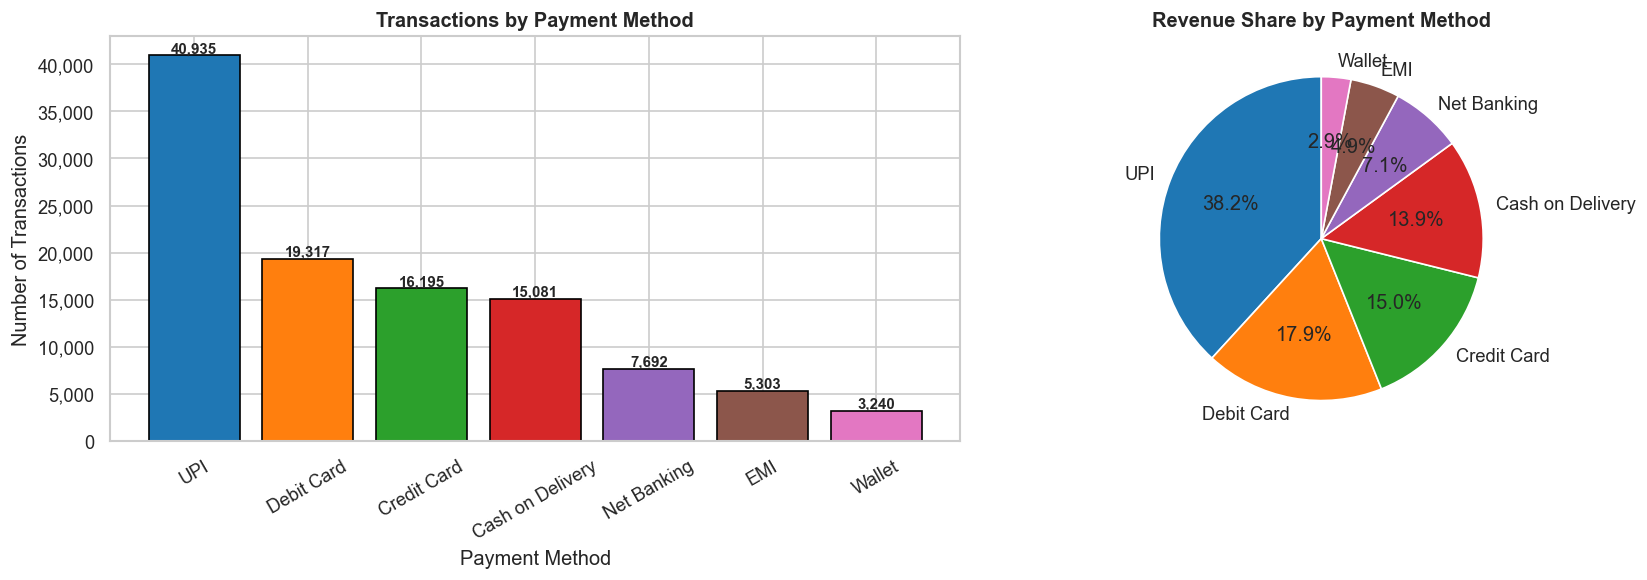

Payment Method Summary Table:


,Payment Type,Number of Transactions,Total Revenue,Average Order Value
5,UPI,40935,"₹1,569,017,509.23 (156.90 Cr)","₹38,329.49"
2,Debit Card,19317,"₹733,371,914.26 (73.34 Cr)","₹37,965.10"
1,Credit Card,16195,"₹617,799,247.94 (61.78 Cr)","₹38,147.53"
0,Cash on Delivery,15081,"₹571,255,000.39 (57.13 Cr)","₹37,879.12"
4,Net Banking,7692,"₹292,115,763.31 (29.21 Cr)","₹37,976.57"
3,EMI,5303,"₹202,375,876.32 (20.24 Cr)","₹38,162.53"
6,Wallet,3240,"₹120,895,502.17 (12.09 Cr)","₹37,313.43"


In [6]:
# =========================
# Section 7: Payment Method Preferences
# =========================

payments_pref = payments.copy()
payments_pref = payments_pref[payments_pref["payment_type"].ne("Unknown")]

payment_summary = (
    payments_pref.groupby("payment_type")
    .agg(
        Transactions=("order_id", "count"),
        Total_Revenue=("payment_value", "sum"),
        Avg_Order_Value=("payment_value", "mean")
    )
    .reset_index()
    .sort_values("Transactions", ascending=False)
)

payment_summary["Total Revenue (₹ Crore)"] = payment_summary["Total_Revenue"] / 1e7

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = sns.color_palette("tab10", n_colors=len(payment_summary))

# Left: transactions bar chart
bars = axes[0].bar(
    payment_summary["payment_type"],
    payment_summary["Transactions"],
    color=colors,
    edgecolor="black"
)
axes[0].set_title("Transactions by Payment Method", fontweight="bold")
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Number of Transactions")
axes[0].yaxis.set_major_formatter(comma_fmt)
axes[0].tick_params(axis="x", rotation=30)

for bar in bars:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Right: revenue share pie chart
axes[1].pie(
    payment_summary["Total_Revenue"],
    labels=payment_summary["payment_type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Revenue Share by Payment Method", fontweight="bold")

plt.tight_layout()
plt.show()

payment_display = payment_summary[["payment_type", "Transactions", "Total_Revenue", "Avg_Order_Value"]].copy()
payment_display["Total_Revenue"] = payment_display["Total_Revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
payment_display["Avg_Order_Value"] = payment_display["Avg_Order_Value"].map(lambda x: f"₹{x:,.2f}")
payment_display.columns = ["Payment Type", "Number of Transactions", "Total Revenue", "Average Order Value"]

print("Payment Method Summary Table:")
display(payment_display)

Repeat Purchase Rate    : 44.7%  (167 of 374 customers)
Avg Order-to-Order Gap  : 139 days
Avg Delivery Time       : 6.4 days
Cancellation Rate       : 9.0%


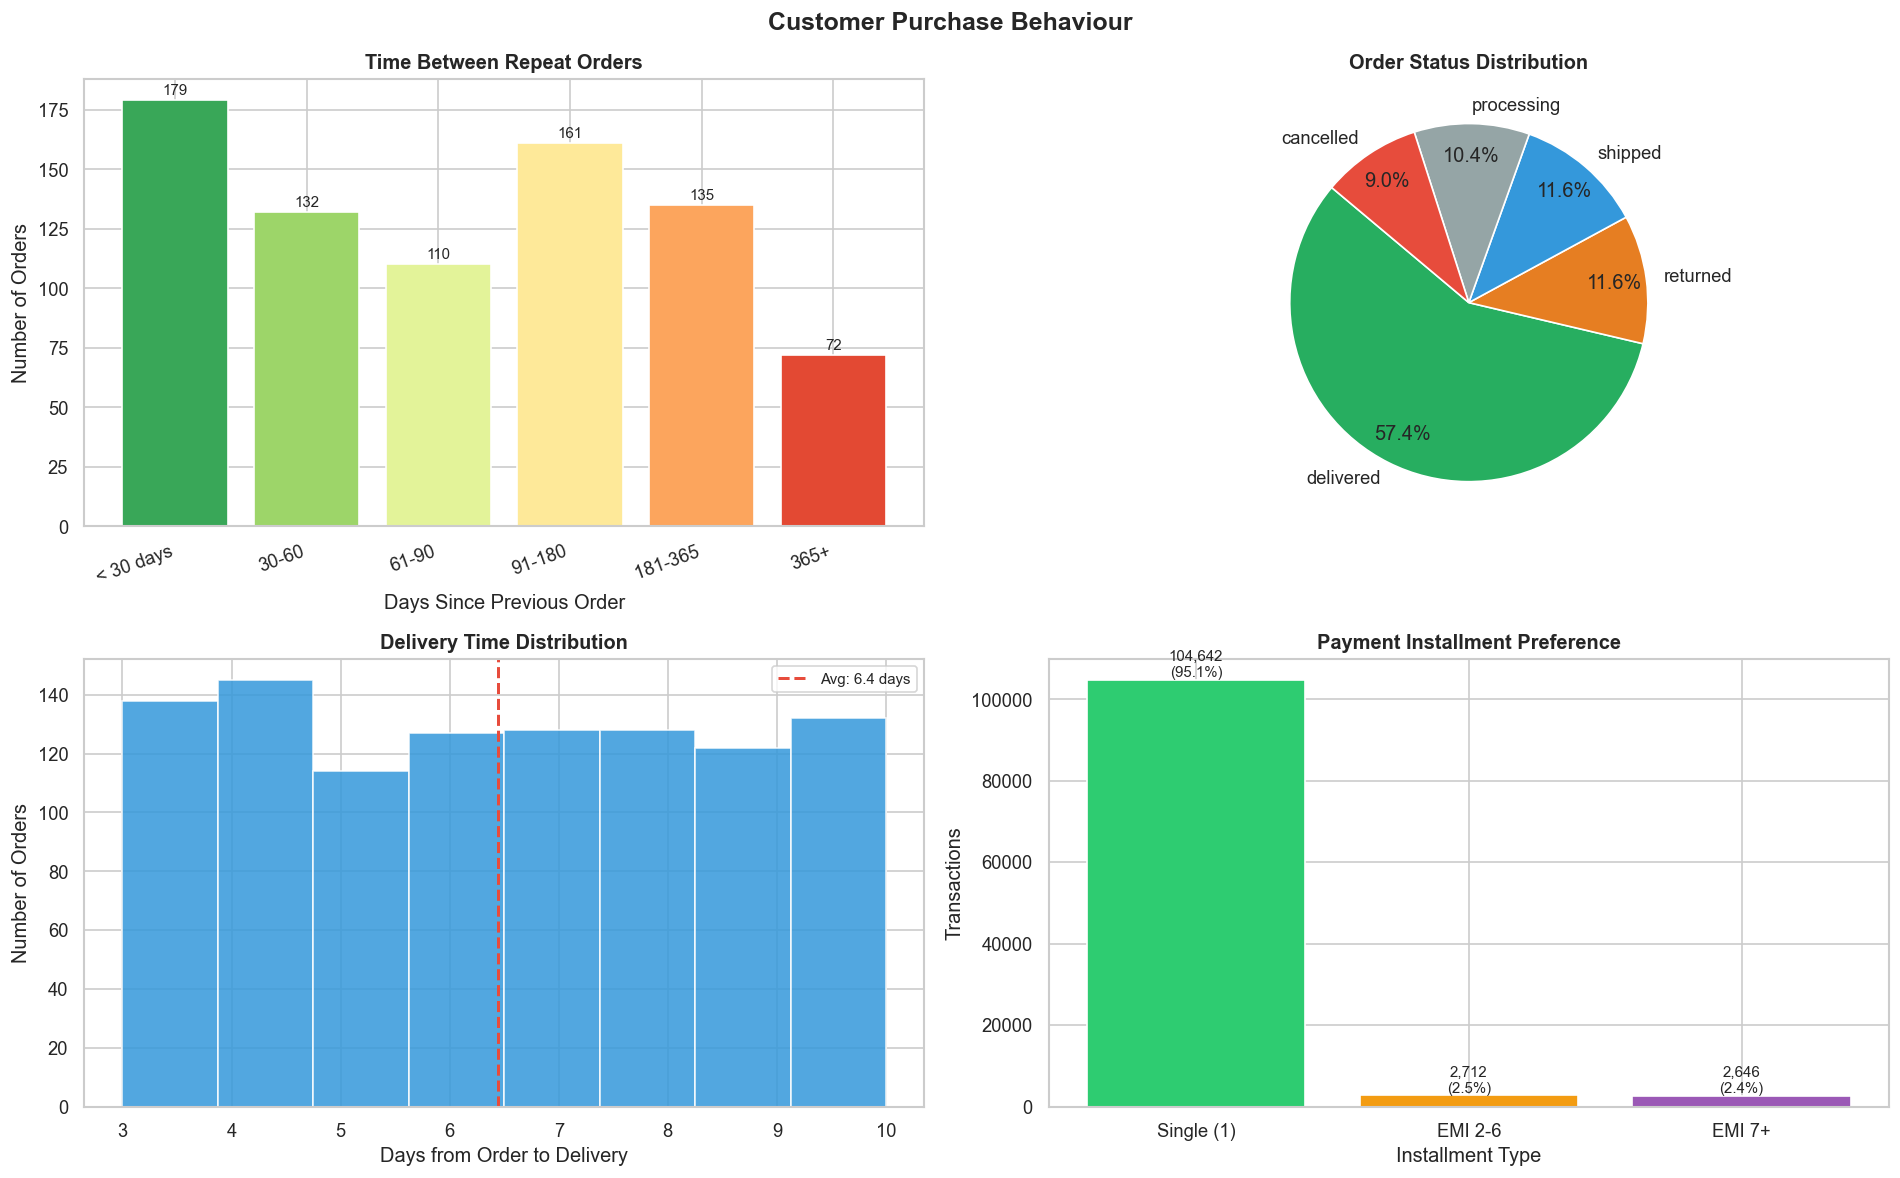


── Order Gap Distribution ──
            Count   Pct
gap_bucket             
< 30 days     179  22.7
30-60         132  16.7
61-90         110  13.9
91-180        161  20.4
181-365       135  17.1
365+           72   9.1

── Order Status Counts ──
              Count
order_status       
delivered       673
returned        136
shipped         136
processing      122
cancelled       105


In [11]:
# =========================
# Section 8: Customer Purchase Behaviour
# =========================

import warnings
warnings.filterwarnings("ignore")

orders_ts = orders.copy()
orders_ts["order_purchase_timestamp"] = pd.to_datetime(
    orders_ts["order_purchase_timestamp"], format="mixed", errors="coerce"
)
orders_ts["order_delivered_timestamp"] = pd.to_datetime(
    orders_ts["order_delivered_timestamp"], format="mixed", errors="coerce"
)

# ── 1. Order-to-Order Gap (repeat customers only) ─────────────────────────────
orders_sorted = orders_ts.sort_values(["customer_id", "order_purchase_timestamp"])
orders_sorted["prev_order"] = orders_sorted.groupby("customer_id")["order_purchase_timestamp"].shift(1)
orders_sorted["order_gap_days"] = (
    orders_sorted["order_purchase_timestamp"] - orders_sorted["prev_order"]
).dt.days
gaps = orders_sorted.dropna(subset=["order_gap_days"])

gap_bins   = [0, 30, 60, 90, 180, 365, float("inf")]
gap_labels = ["< 30 days", "30-60", "61-90", "91-180", "181-365", "365+"]
gaps["gap_bucket"] = pd.cut(gaps["order_gap_days"], bins=gap_bins, labels=gap_labels, right=True)
gap_dist = gaps["gap_bucket"].value_counts().sort_index()

# ── 2. Order Status Breakdown ─────────────────────────────────────────────────
status_counts = orders_ts["order_status"].value_counts()

# ── 3. Delivery Time Distribution ─────────────────────────────────────────────
orders_ts["delivery_days"] = (
    orders_ts["order_delivered_timestamp"] - orders_ts["order_purchase_timestamp"]
).dt.days
delivered_df = orders_ts.dropna(subset=["delivery_days"])
avg_delivery = delivered_df["delivery_days"].mean()

# ── 4. Installment Preference ─────────────────────────────────────────────────
pay_inst = payments.copy()
pay_inst["installment_type"] = pay_inst["payment_installments"].apply(
    lambda x: "Single (1)" if x == 1 else ("EMI 2-6" if x <= 6 else "EMI 7+")
)
inst_counts = pay_inst["installment_type"].value_counts()

# ── KPIs ──────────────────────────────────────────────────────────────────────
repeat_customers = (orders_ts.groupby("customer_id")["order_id"].nunique() > 1).sum()
total_customers  = orders_ts["customer_id"].nunique()
repeat_rate      = repeat_customers / total_customers * 100
avg_gap          = gaps["order_gap_days"].mean()
cancellation_rt  = status_counts.get("cancelled", 0) / len(orders_ts) * 100

print(f"Repeat Purchase Rate    : {repeat_rate:.1f}%  ({repeat_customers:,} of {total_customers:,} customers)")
print(f"Avg Order-to-Order Gap  : {avg_gap:.0f} days")
print(f"Avg Delivery Time       : {avg_delivery:.1f} days")
print(f"Cancellation Rate       : {cancellation_rt:.1f}%")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Customer Purchase Behaviour", fontsize=15, fontweight="bold")

# Top-left — Order gap between repeat purchases
ax1 = axes[0, 0]
colors_gap = sns.color_palette("RdYlGn_r", len(gap_dist))
bars1 = ax1.bar(gap_dist.index.astype(str), gap_dist.values, color=colors_gap, edgecolor="white")
ax1.set_title("Time Between Repeat Orders", fontweight="bold")
ax1.set_xlabel("Days Since Previous Order")
ax1.set_ylabel("Number of Orders")
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)

# Top-right — Order status pie
ax2 = axes[0, 1]
status_colors = {"delivered": "#27ae60", "cancelled": "#e74c3c",
                 "returned":  "#e67e22", "shipped":   "#3498db",
                 "processing": "#95a5a6"}
colors_s = [status_colors.get(s, "#bdc3c7") for s in status_counts.index]
ax2.pie(status_counts.values, labels=status_counts.index,
        colors=colors_s, autopct="%1.1f%%", pctdistance=0.82, startangle=140)
ax2.set_title("Order Status Distribution", fontweight="bold")

# Bottom-left — Delivery time histogram
ax3 = axes[1, 0]
ax3.hist(delivered_df["delivery_days"].dropna(), bins=8,
         color="#3498db", edgecolor="white", alpha=0.85)
ax3.axvline(avg_delivery, color="#e74c3c", linestyle="--", linewidth=1.8,
            label=f"Avg: {avg_delivery:.1f} days")
ax3.set_title("Delivery Time Distribution", fontweight="bold")
ax3.set_xlabel("Days from Order to Delivery")
ax3.set_ylabel("Number of Orders")
ax3.legend(fontsize=9)

# Bottom-right — Installment preference
ax4 = axes[1, 1]
inst_palette = ["#2ecc71", "#f39c12", "#9b59b6"]
bars4 = ax4.bar(inst_counts.index, inst_counts.values,
                color=inst_palette[:len(inst_counts)], edgecolor="white")
ax4.set_title("Payment Installment Preference", fontweight="bold")
ax4.set_xlabel("Installment Type")
ax4.set_ylabel("Transactions")
for bar in bars4:
    pct = bar.get_height() / inst_counts.sum() * 100
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{int(bar.get_height()):,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("\n── Order Gap Distribution ──")
print(gap_dist.to_frame(name="Count").assign(Pct=lambda x: (x["Count"]/x["Count"].sum()*100).round(1)))
print("\n── Order Status Counts ──")
print(status_counts.to_frame(name="Count"))


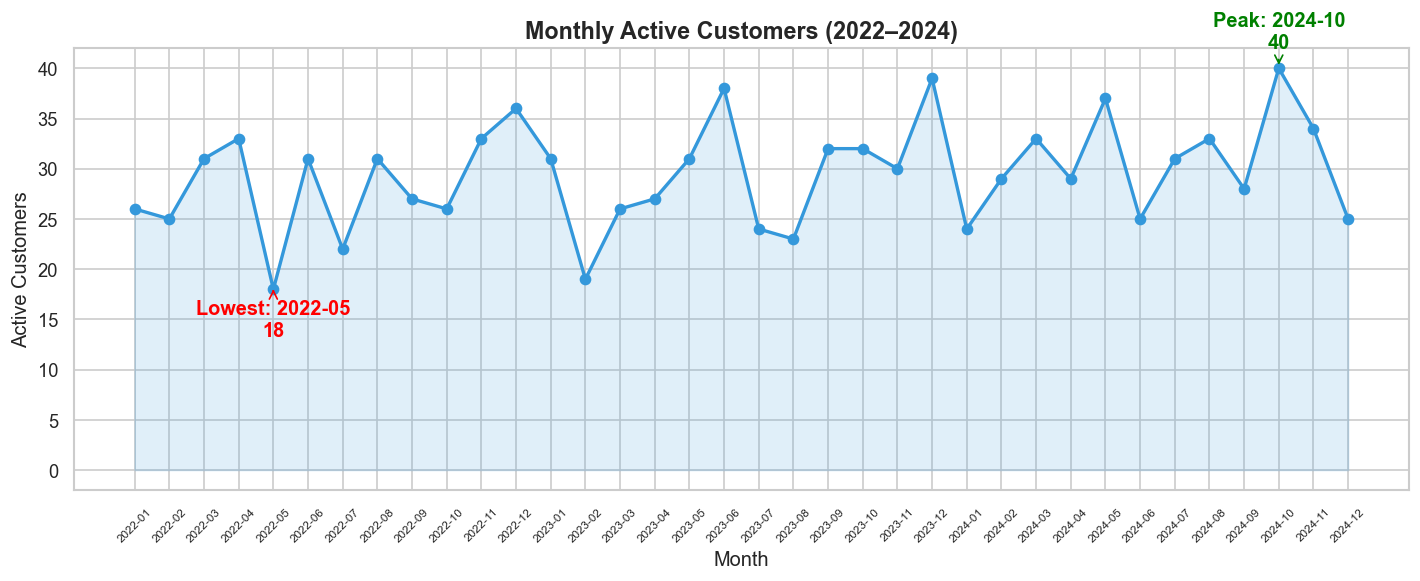

In [7]:
# =========================
# Section 9: Monthly Active Customers (MAC) Trend
# =========================

mac_df = orders.copy()
mac_df["month"] = mac_df["order_purchase_timestamp"].dt.to_period("M")

mac_summary = (
    mac_df.groupby("month")["customer_id"]
    .nunique()
    .reset_index(name="Active Customers")
    .sort_values("month")
)

mac_summary["month_str"] = mac_summary["month"].astype(str)

peak_idx = mac_summary["Active Customers"].idxmax()
low_idx = mac_summary["Active Customers"].idxmin()

fig, ax = plt.subplots(figsize=(12, 5))

x = mac_summary["month_str"]
y = mac_summary["Active Customers"]

ax.plot(x, y, color="#3498db", marker="o", linewidth=2)
ax.fill_between(x, y, alpha=0.15, color="#3498db")

ax.set_title("Monthly Active Customers (2022–2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Active Customers")
ax.yaxis.set_major_formatter(comma_fmt)
ax.tick_params(axis="x", rotation=45, labelsize=7)

# Peak annotation
ax.annotate(
    f"Peak: {mac_summary.loc[peak_idx, 'month_str']}\n{mac_summary.loc[peak_idx, 'Active Customers']:,.0f}",
    xy=(mac_summary.loc[peak_idx, "month_str"], mac_summary.loc[peak_idx, "Active Customers"]),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    color="green",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="green")
)

# Lowest annotation
ax.annotate(
    f"Lowest: {mac_summary.loc[low_idx, 'month_str']}\n{mac_summary.loc[low_idx, 'Active Customers']:,.0f}",
    xy=(mac_summary.loc[low_idx, "month_str"], mac_summary.loc[low_idx, "Active Customers"]),
    xytext=(0, -28),
    textcoords="offset points",
    ha="center",
    color="red",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red")
)

plt.tight_layout()
plt.show()

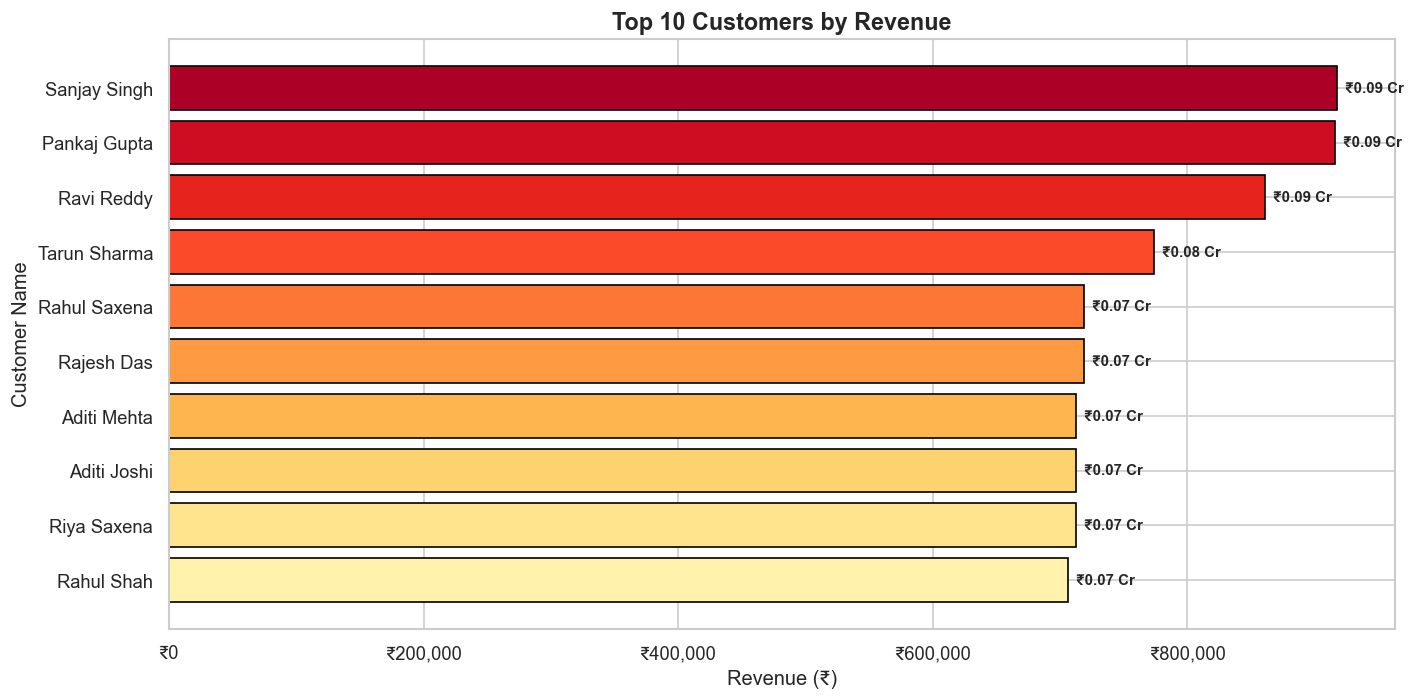

Top 10 Customers Table:


,Customer Name,Customer State,Total Orders,Total Revenue
213,Sanjay Singh,Punjab,21,"₹917,377.79 (0.09 Cr)"
169,Pankaj Gupta,Delhi,16,"₹916,377.24 (0.09 Cr)"
357,Ravi Reddy,Telangana,17,"₹861,018.22 (0.09 Cr)"
188,Tarun Sharma,Telangana,20,"₹773,882.45 (0.08 Cr)"
28,Rahul Saxena,Rajasthan,20,"₹718,870.71 (0.07 Cr)"
175,Rajesh Das,Karnataka,7,"₹718,598.27 (0.07 Cr)"
197,Aditi Mehta,Punjab,17,"₹712,956.97 (0.07 Cr)"
369,Aditi Joshi,Odisha,20,"₹712,902.47 (0.07 Cr)"
202,Riya Saxena,Gujarat,14,"₹712,777.62 (0.07 Cr)"
125,Rahul Shah,Karnataka,10,"₹705,905.07 (0.07 Cr)"


In [8]:
# =========================
# Section 10: Top 10 Customers by Revenue
# =========================

top_base = orders.merge(payments, on="order_id", how="left").merge(
    customers[["customer_id", "customer_name", "customer_state"]],
    on="customer_id",
    how="left"
)

top_customers = (
    top_base.groupby(["customer_id", "customer_name", "customer_state"])
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    top_customers["customer_name"],
    top_customers["total_revenue"],
    color=sns.color_palette("YlOrRd_r", n_colors=len(top_customers)),
    edgecolor="black"
)

ax.invert_yaxis()
ax.set_title("Top 10 Customers by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (₹)")
ax.set_ylabel("Customer Name")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("₹{x:,.0f}"))

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"  ₹{width/1e7:,.2f} Cr",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

top_display = top_customers[["customer_name", "customer_state", "total_orders", "total_revenue"]].copy()
top_display["total_revenue"] = top_display["total_revenue"].map(lambda x: f"₹{x:,.2f} ({x/1e7:,.2f} Cr)")
top_display.columns = ["Customer Name", "Customer State", "Total Orders", "Total Revenue"]

print("Top 10 Customers Table:")
display(top_display)

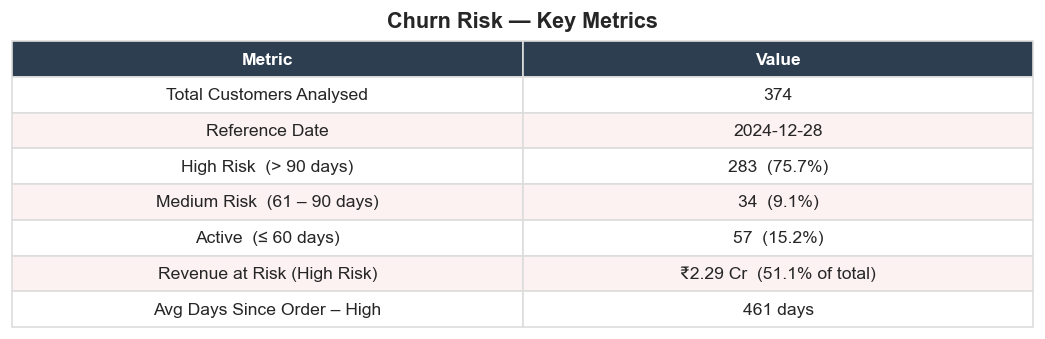

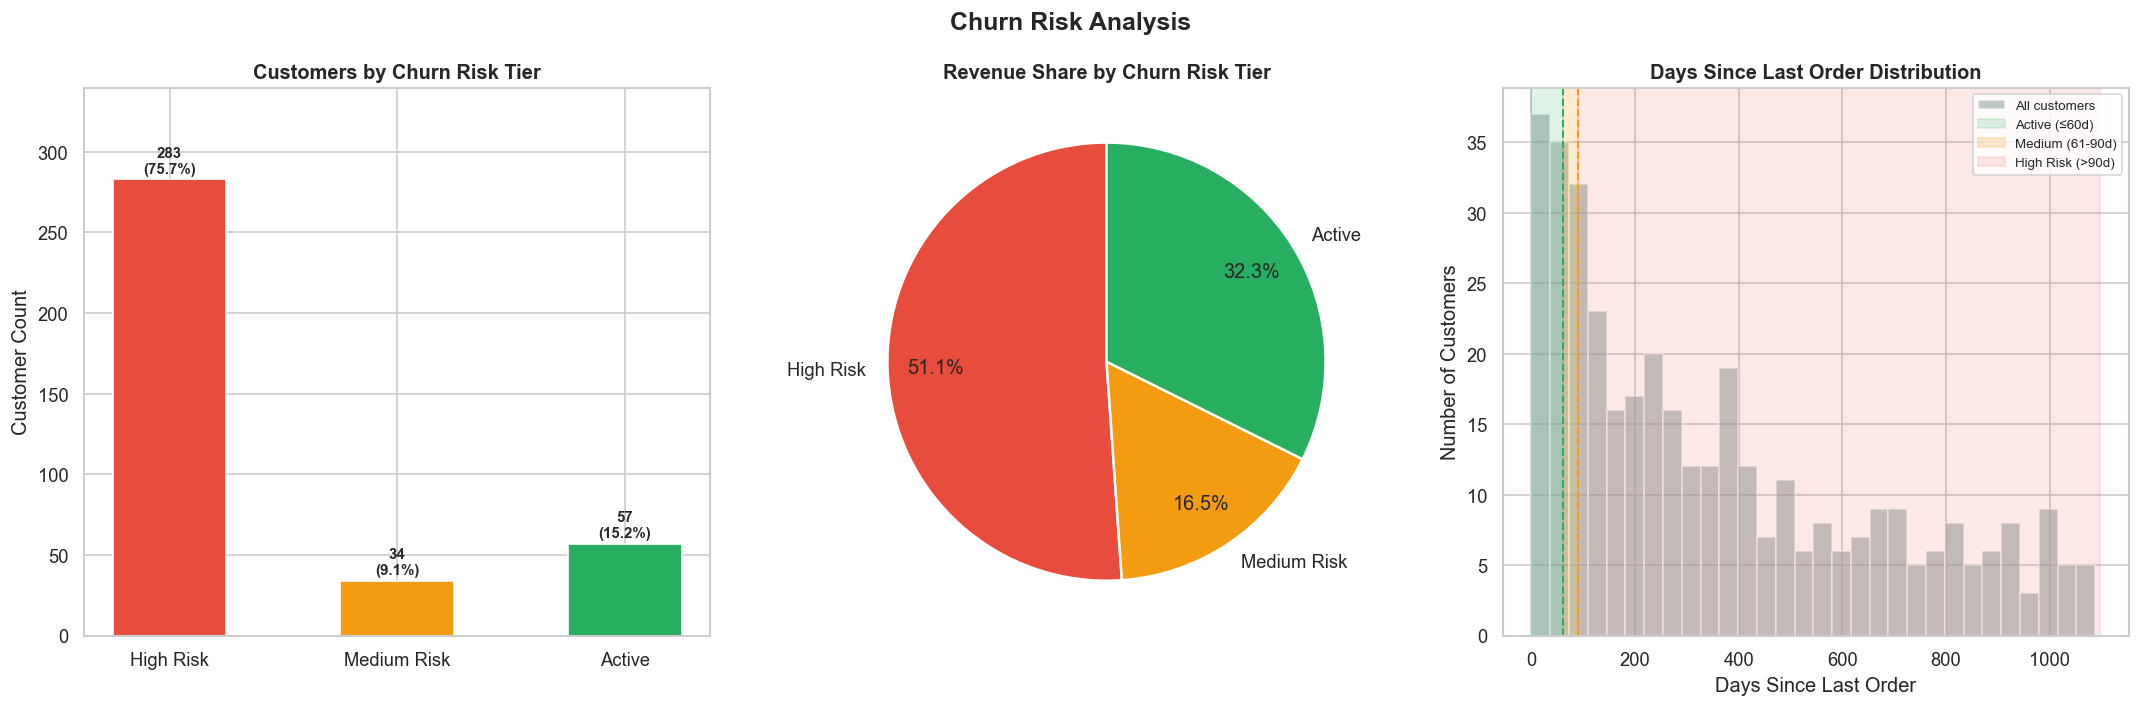


── Top 15 High Risk Customers by Revenue ──
customer_name customer_state  days_since_last_order  total_orders  total_revenue churn_risk
   Rajesh Das      Karnataka                    376             7      718598.27  High Risk
   Nikhil Rao        Gujarat                    123            17      523638.48  High Risk
Anjali Tiwari     Tamil Nadu                    383             3      440219.44  High Risk
   Amit Naidu      Karnataka                    182             7      380147.15  High Risk
    Kiran Rao         Kerala                     91             8      368817.19  High Risk
 Arjun Mishra Madhya Pradesh                    140             4      366747.47  High Risk
   Aarav Nair      Telangana                    101             7      365671.96  High Risk
 Yasmin Joshi          Bihar                     98             6      351562.58  High Risk
   Mohan Bose         Odisha                     93             8      344938.87  High Risk
  Gaurav Shah      Rajasthan       

In [13]:
# =========================
# Section 11: Churn Risk Analysis & Export
# =========================

# ── Build churn base ──────────────────────────────────────────────────────────
churn_base = orders.merge(payments, on="order_id", how="left")

churn_df = (
    churn_base.groupby("customer_id")
    .agg(
        last_order_date=("order_purchase_timestamp", "max"),
        total_orders=("order_id",         "nunique"),
        total_revenue=("payment_value",    "sum"),
    )
    .reset_index()
)

reference_date = churn_base["order_purchase_timestamp"].max()
churn_df["days_since_last_order"] = (reference_date - churn_df["last_order_date"]).dt.days

# ── Assign churn risk tier ────────────────────────────────────────────────────
def churn_label(days):
    if days <= 60:
        return "Active"
    elif days <= 90:
        return "Medium Risk"
    else:
        return "High Risk"

churn_df["churn_risk"] = churn_df["days_since_last_order"].apply(churn_label)

# ── Merge customer info ───────────────────────────────────────────────────────
churn_df = churn_df.merge(
    customers[["customer_id", "customer_name", "customer_city", "customer_state"]],
    on="customer_id", how="left"
)

# ── Summary stats ─────────────────────────────────────────────────────────────
total_rev   = churn_df["total_revenue"].sum()
risk_summary = (
    churn_df.groupby("churn_risk")
    .agg(
        Customer_Count=("customer_id",    "count"),
        Avg_Days=("days_since_last_order", "mean"),
        Total_Revenue=("total_revenue",    "sum"),
    )
    .reset_index()
)
risk_summary["Revenue_Cr"]  = risk_summary["Total_Revenue"] / 1e7
risk_summary["Revenue_Pct"] = risk_summary["Total_Revenue"] / total_rev * 100
risk_summary["Cust_Pct"]    = risk_summary["Customer_Count"] / risk_summary["Customer_Count"].sum() * 100

# enforce display order
order_map = {"High Risk": 0, "Medium Risk": 1, "Active": 2}
risk_summary["_ord"] = risk_summary["churn_risk"].map(order_map)
risk_summary = risk_summary.sort_values("_ord").drop(columns="_ord").reset_index(drop=True)

# ── KPI styled table ──────────────────────────────────────────────────────────
high  = risk_summary[risk_summary["churn_risk"] == "High Risk"].iloc[0]
med   = risk_summary[risk_summary["churn_risk"] == "Medium Risk"].iloc[0]
actv  = risk_summary[risk_summary["churn_risk"] == "Active"].iloc[0]

kpis = [
    ("Total Customers Analysed",       f"{len(churn_df):,}"),
    ("Reference Date",                 str(reference_date.date())),
    ("High Risk  (> 90 days)",         f"{int(high['Customer_Count']):,}  ({high['Cust_Pct']:.1f}%)"),
    ("Medium Risk  (61 – 90 days)",    f"{int(med['Customer_Count']):,}  ({med['Cust_Pct']:.1f}%)"),
    ("Active  (≤ 60 days)",            f"{int(actv['Customer_Count']):,}  ({actv['Cust_Pct']:.1f}%)"),
    ("Revenue at Risk (High Risk)",    f"₹{high['Revenue_Cr']:.2f} Cr  ({high['Revenue_Pct']:.1f}% of total)"),
    ("Avg Days Since Order – High",    f"{high['Avg_Days']:.0f} days"),
]

fig0, ax0 = plt.subplots(figsize=(9, 3))
ax0.axis("off")
tbl = ax0.table(cellText=kpis, colLabels=["Metric", "Value"], cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1.3, 1.9)
row_colors = ["#ffffff", "#fdf2f2"]
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#fdf2f2")
    cell.set_edgecolor("#dddddd")
ax0.set_title("Churn Risk — Key Metrics", fontsize=13, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

# ── Main figure : 3 charts ────────────────────────────────────────────────────
risk_colors = {"High Risk": "#e74c3c", "Medium Risk": "#f39c12", "Active": "#27ae60"}
colors_ordered = [risk_colors[r] for r in risk_summary["churn_risk"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Churn Risk Analysis", fontsize=15, fontweight="bold")

# Left — Customer count bar
ax1 = axes[0]
bars1 = ax1.bar(risk_summary["churn_risk"], risk_summary["Customer_Count"],
                color=colors_ordered, edgecolor="white", width=0.5)
ax1.set_title("Customers by Churn Risk Tier", fontweight="bold")
ax1.set_ylabel("Customer Count")
for bar, row in zip(bars1, risk_summary.itertuples()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f"{int(row.Customer_Count):,}\n({row.Cust_Pct:.1f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_ylim(0, risk_summary["Customer_Count"].max() * 1.2)

# Middle — Revenue at risk pie
ax2 = axes[1]
ax2.pie(
    risk_summary["Total_Revenue"],
    labels=risk_summary["churn_risk"],
    colors=colors_ordered,
    autopct="%1.1f%%",
    pctdistance=0.78,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax2.set_title("Revenue Share by Churn Risk Tier", fontweight="bold")

# Right — Days since last order histogram with risk zones shaded
ax3 = axes[2]
ax3.hist(churn_df["days_since_last_order"], bins=30, color="#95a5a6",
         edgecolor="white", alpha=0.6, label="All customers")
ax3.axvspan(0,   60,  alpha=0.15, color="#27ae60", label="Active (≤60d)")
ax3.axvspan(60,  90,  alpha=0.20, color="#f39c12", label="Medium (61-90d)")
ax3.axvspan(90,  churn_df["days_since_last_order"].max() + 10,
            alpha=0.12, color="#e74c3c", label="High Risk (>90d)")
ax3.axvline(60, color="#27ae60", linestyle="--", linewidth=1.2)
ax3.axvline(90, color="#f39c12", linestyle="--", linewidth=1.2)
ax3.set_title("Days Since Last Order Distribution", fontweight="bold")
ax3.set_xlabel("Days Since Last Order")
ax3.set_ylabel("Number of Customers")
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Top 15 High Risk customers by revenue ─────────────────────────────────────
high_risk_top = (
    churn_df[churn_df["churn_risk"] == "High Risk"]
    .sort_values("total_revenue", ascending=False)
    .head(15)[["customer_name", "customer_state", "days_since_last_order",
               "total_orders", "total_revenue", "churn_risk"]]
    .reset_index(drop=True)
)
print("\n── Top 15 High Risk Customers by Revenue ──")
print(high_risk_top.to_string(index=False))

# ── Export churn_risk_powerbi.csv ─────────────────────────────────────────────
churn_export_cols = [
    "customer_id", "customer_name", "customer_city", "customer_state",
    "last_order_date", "days_since_last_order",
    "total_orders", "total_revenue", "churn_risk"
]
churn_df[churn_export_cols].to_csv("churn_risk_powerbi.csv", index=False)
print(f"\nExported churn_risk_powerbi.csv  →  {len(churn_df):,} rows")
print(f"  High Risk : {int(high['Customer_Count']):,} customers  |  Revenue at risk: ₹{high['Revenue_Cr']:.2f} Cr")
print(f"  Medium Risk: {int(med['Customer_Count']):,} customers")
print(f"  Active    : {int(actv['Customer_Count']):,} customers")
print("\n── Risk Summary Table ──")
print(risk_summary[["churn_risk","Customer_Count","Cust_Pct","Revenue_Cr","Revenue_Pct","Avg_Days"]].to_string(index=False))


In [14]:
# =========================
# Section 12: Export Customer Summary for Power BI
# =========================

powerbi_base = orders.merge(payments, on="order_id", how="left")

customer_summary = (
    powerbi_base.groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_value", "sum"),
        avg_order_value=("payment_value", "mean"),
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_summary = customer_summary.merge(
    customers[[
        "customer_id",
        "customer_name",
        "customer_city",
        "customer_state",
        "customer_since"
    ]],
    on="customer_id",
    how="left"
)

# Derived segment
customer_summary["segment"] = np.select(
    [
        customer_summary["total_orders"].eq(1),
        customer_summary["total_orders"].between(2, 5),
        customer_summary["total_orders"].ge(6)
    ],
    ["One-Time", "Occasional", "Loyal"],
    default="Unknown"
)

# Derived CLV tier
customer_summary["clv_tier"] = pd.cut(
    customer_summary["total_revenue"],
    bins=[0, 10000, 50000, 200000, np.inf],
    labels=["Low", "Medium", "High", "Premium"],
    include_lowest=True
)

# Export
output_file = "customer_summary_for_powerbi.csv"
customer_summary.to_csv(output_file, index=False)

print(f"Exported {len(customer_summary):,} rows to {output_file}")
display(customer_summary.head(5))

Exported 374 rows to customer_summary_for_powerbi.csv


,customer_id,total_orders,total_revenue,avg_order_value,first_order_date,last_order_date,customer_name,customer_city,customer_state,customer_since,segment,clv_tier
0,CUST00081,2,44664.44,22332.220000,2022-09-04,2024-10-17,Arjun Pandey,Rohini,Delhi,2022-03-19,Occasional,Medium
1,CUST00148,2,65579.57,32789.785000,2023-10-24,2024-05-21,Kavya Nair,Chennai,Tamil Nadu,2022-11-05,Occasional,High
2,CUST00169,1,42951.37,42951.370000,2023-11-28,2023-11-28,Varun Pillai,Mumbai,Maharashtra,2019-03-19,One-Time,Medium
3,CUST00293,1,24755.57,24755.570000,2022-12-29,2022-12-29,Vijay Pillai,Agra,Uttar Pradesh,2020-05-21,One-Time,Medium
4,CUST00298,9,322136.17,35792.907778,2022-04-30,2024-10-23,Ravi Patel,Howrah,West Bengal,2021-10-26,Loyal,Premium
